In [1]:
from imolcraft.calculator import DihedralCalculator, load_g16scan
from imolcraft.io.rdkit import atoms2rdkit
from imolcraft.trainer.dmff_utils import  *
from imolcraft.trainer import DihedralTrainer
from imolcraft.trainer.loss import mse_energy
from ase.io import read
from ase.visualize import view
from jax import value_and_grad, jit, vmap

import matplotlib.pyplot as plt
import copy

/Users/srak/miniconda3/envs/imc/lib/python3.11/site-packages/psi4/driver/procrouting/solvent/ddx.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/Users/srak/miniconda3/envs/imc/lib/python3.11/site-packages/dmff/admp/qeq.py:33: UserWarning: jaxopt not found, QEQ cannot be used.
  warnings.warn("jaxopt not found, QEQ cannot be used.")
Warning on use of the timeseries module: If the inherent timescales of the system are long compared to those being analyzed, this statistical inefficiency may be an underestimate.  The estimate presumes the use of many statistically independent samples.  Tests should be performed to assess whether this condition is satisfied.   Be cautious in the interpretation of the data.


In [3]:
pdbfile = "dmc.pdb"
atoms = read(pdbfile)
mol, mol2d, _ = atoms2rdkit(atoms)
calculator = DihedralCalculator(atoms, "dmc", directory="temp_directory")
calculator.scan_list

[[1, 0, 2, 8], [1, 0, 3, 4], [0, 2, 8, 9], [0, 3, 4, 5]]

In [4]:
# mol2d で [1, 0, 3, 4]のdihedralをハイライト
from rdkit.Chem import Draw
from rdkit.Chem import rdMolTransforms
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdDepictor
from rdkit.Chem.Draw import rdMolDraw2D

# H原子は表示しない
rdDepictor.Compute2DCoords(mol2d)
d = rdMolDraw2D.MolDraw2DCairo(500, 500)

#d.DrawMolecule(mol2d, highlightAtoms=[1, 0, 3, 4])でハイライトの色は薄め
highlight_atoms = [1, 0, 3, 4]
highlight_atom_colors = {idx: (1, 0.5, 0.5) for idx in highlight_atoms}
d.DrawMolecule(mol2d, highlightAtoms=highlight_atoms, highlightAtomColors=highlight_atom_colors)
d.FinishDrawing()

with open("dmc_dihedral.png", "wb") as f:
    f.write(d.GetDrawingText())

In [5]:
# # check dihedral atom index -> 1,0,2,8
# view(load_g16scan("dmc_dihed_0.log")[2])
# # check dihedral atom index -> 0,2,8,9
# view(load_g16scan("dmc_dihed_2.log")[2])

In [6]:
calculator.scan_list  = [calculator.scan_list[0] , calculator.scan_list[2]]
calculator.qm_calculators = [calculator.qm_calculators[0], calculator.qm_calculators[2]]
calculator.ff_calculators = [calculator.ff_calculators[0], calculator.ff_calculators[2]]
calculator.qm_scan = [calculator.qm_scan[0], calculator.qm_scan[2]]
calculator.ff_scan = [calculator.ff_scan[0], calculator.ff_scan[2]]

calculator.qm_scan[0]["angle_deg"], \
calculator.qm_scan[0]["energy_kjmol"], \
calculator.qm_scan[0]["atoms"], \
      = load_g16scan("dmc_dihed_0.log")

calculator.qm_scan[1]["angle_deg"], \
calculator.qm_scan[1]["energy_kjmol"], \
calculator.qm_scan[1]["atoms"], \
      = load_g16scan("dmc_dihed_2.log")

In [7]:
calculator.do_ffscan("dmc.xml", angles="QM", ini_geom="FF")
# calculator.do_ffscan("dmc1_best.xml", angles="QM", ini_geom="FF")

In [8]:
ff0_origin = copy.deepcopy(calculator.ff_scan[0]["energy_kjmol"])
ff1_origin = copy.deepcopy(calculator.ff_scan[1]["energy_kjmol"])

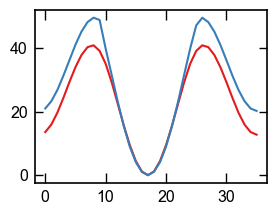

In [9]:
plt.plot(calculator.qm_scan[0]["energy_kjmol"])
plt.plot(calculator.ff_scan[0]["energy_kjmol"])

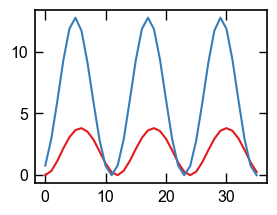

In [10]:
plt.plot(calculator.qm_scan[1]["energy_kjmol"])
plt.plot(calculator.ff_scan[1]["energy_kjmol"])

In [11]:
len(calculator.qm_scan)

2

In [12]:
def loss_energy(ffparams, ff, topology, positions, pairs, y_gt):
    ff_d = update_ffinfo_from_params(ff, ffparams)
    ffparams_wo_charge = {}
    for key in ffparams.keys():
        if key == "NonbondedForce":
            ffparams_wo_charge[key] = {}
            for key2 in ffparams[key].keys():
                if key2 != "charges":
                    ffparams_wo_charge[key][key2] = ffparams[key][key2]
        elif key == "VsiteForce":
            pass
        else:
            ffparams_wo_charge[key] = ffparams[key]

    pots = ff_d.createPotential(topology) # should be pdb topology wo vsites
    efunc = pots.getPotentialFunc()
    batched_efunc = vmap(lambda x: efunc(x, None, pairs[0], ffparams_wo_charge))
    e_ff = batched_efunc(positions)
    e_ff = e_ff 
    y_gt = y_gt 
    # print(f"e_ff: {e_ff}")
    # print(f"y_gt: {y_gt}")
    loss = mse_energy(e_ff, y_gt, weight_scheme="boltzmann", norm_var=True, zeropoint="qmmin")
    # print(f"loss: {loss}")
    return loss

In [13]:
tr = DihedralTrainer(
    ffxml="dmc.xml",
    pdbfile=pdbfile,
    calculator=calculator,
    opt_fftypes=["PeriodicTorsionForce/proper_k"],
    loss_fn=loss_energy,
    relax_steps=1,
    lr=0.1,
    clip=0.5
)

In [12]:
tr.setup()

In [13]:
tr.fit(steps=10)

Epoch 0 completed in 21.22 seconds.
Loss:  10.643234262804274
Best Loss:  10.643234262804274 at epoch  0
Epoch 1 completed in 17.31 seconds.
Loss:  8.322564771020513
Best Loss:  8.322564771020513 at epoch  1
Epoch 2 completed in 16.14 seconds.
Loss:  7.191964271973056
Best Loss:  7.191964271973056 at epoch  2
Epoch 3 completed in 15.84 seconds.
Loss:  6.1658276745374785
Best Loss:  6.1658276745374785 at epoch  3
Epoch 4 completed in 16.17 seconds.
Loss:  5.21264262861611
Best Loss:  5.21264262861611 at epoch  4
Epoch 5 completed in 16.04 seconds.
Loss:  4.351623025171065
Best Loss:  4.351623025171065 at epoch  5
Epoch 6 completed in 15.93 seconds.
Loss:  3.5876071311430544
Best Loss:  3.5876071311430544 at epoch  6
Epoch 7 completed in 15.93 seconds.
Loss:  2.908984414422887
Best Loss:  2.908984414422887 at epoch  7
Epoch 8 completed in 16.06 seconds.
Loss:  2.321596814458952
Best Loss:  2.321596814458952 at epoch  8
Epoch 9 completed in 16.05 seconds.
Loss:  1.8136664715318724
Best Lo

In [14]:
tr.relax_steps = 100
tr.fit(steps=3000)

Epoch 11 completed in 0.12 seconds.
Loss:  1.0488911240439587
Best Loss:  1.0488911240439587 at epoch  11
Epoch 12 completed in 0.12 seconds.
Loss:  0.7779694602312412
Best Loss:  0.7779694602312412 at epoch  12
Epoch 13 completed in 0.12 seconds.
Loss:  0.5743737323182264
Best Loss:  0.5743737323182264 at epoch  13
Epoch 14 completed in 0.12 seconds.
Loss:  0.43110185019604386
Best Loss:  0.43110185019604386 at epoch  14
Epoch 15 completed in 0.12 seconds.
Loss:  0.34046267511371386
Best Loss:  0.34046267511371386 at epoch  15
Epoch 16 completed in 0.12 seconds.
Loss:  0.29426571399756185
Best Loss:  0.29426571399756185 at epoch  16
Epoch 17 completed in 0.12 seconds.
Loss:  0.2840569178914297
Best Loss:  0.2840569178914297 at epoch  17
Epoch 18 completed in 0.12 seconds.
Loss:  0.30138853915095026
Best Loss:  0.2840569178914297 at epoch  17
Epoch 19 completed in 0.12 seconds.
Loss:  0.3381046517415001
Best Loss:  0.2840569178914297 at epoch  17
Epoch 20 completed in 0.12 seconds.
Los

KeyboardInterrupt: 

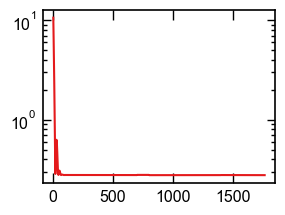

In [15]:
# plt.xscale("log")
plt.yscale("log")
plt.plot(tr.epochs, tr.losses)

In [ ]:
# view(calculator.ff_scan[0]["atoms"])

In [16]:
calculator.do_ffscan("dmc1_best.xml", angles="QM", ini_geom="FF")

Text(0, 0.5, 'Energy (kJ/mol)')

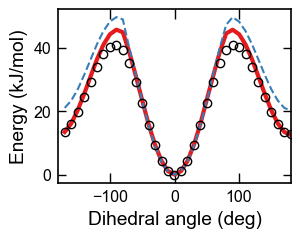

In [34]:
plt.xlim(-180,180)
plt.plot(np.array(calculator.ff_scan[0]["angle_deg"]), calculator.ff_scan[0]["energy_kjmol"], linewidth=3)
plt.plot(calculator.ff_scan[0]["angle_deg"], ff0_origin, linestyle='--')
plt.plot(calculator.qm_scan[0]["angle_deg"], calculator.qm_scan[0]["energy_kjmol"], marker="o", linestyle='None', color="black", fillstyle='none') # 白抜き
plt.xlabel("Dihedral angle (deg)")
plt.ylabel("Energy (kJ/mol)")
# plt.plot(np.array(tr.calculator.ff_scan[0]["angle_deg"])-180, tr.calculator.ff_scan[0]["energy_kjmol"], marker="o")
# plt.plot(np.array(tr.calculator.ff_scan[0]["angle_deg"])+180, tr.calculator.ff_scan[0]["energy_kjmol"], marker="o")

Text(0, 0.5, 'Energy (kJ/mol)')

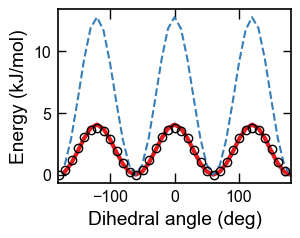

In [37]:
plt.xlim(-180,180)
plt.plot(np.array(calculator.ff_scan[1]["angle_deg"]), calculator.ff_scan[1]["energy_kjmol"], linewidth=3)
plt.plot(calculator.ff_scan[1]["angle_deg"], ff1_origin, linestyle='--')
plt.plot(calculator.qm_scan[1]["angle_deg"], calculator.qm_scan[1]["energy_kjmol"], marker="o", linestyle='None', color="black", fillstyle='none') # 白抜き
plt.xlabel("Dihedral angle (deg)")
plt.ylabel("Energy (kJ/mol)")
# plt.plot(np.array(tr.calculator.ff_scan[0]["angle_deg"])-180, tr.calculator.ff_scan[0]["energy_kjmol"], marker="o")
# plt.plot(np.array(tr.calculator.ff_scan[0]["angle_deg"])+180, tr.calculator.ff_scan[0]["energy_kjmol"], marker="o")